# Nike FY2027-FY2031 operating scenarios

This independent portfolio analysis extends the reconciled FY2022-FY2026 SEC-derived history into documented base, bull, and bear project analyst scenarios. It is an operating forecast, not Nike guidance, a probability assessment, or a valuation. It is not an investment recommendation. The information cutoff is September 7, 2026.

## Scope and source boundary

Historical reported facts, company commentary, analyst assumptions, and calculated forecast outputs remain separately identified. Nike's FY2027 first-quarter results were scheduled for October 1, 2026 and are excluded. Detailed evidence is in the [forecast source register](../config/forecast_sources.csv), [assumption register](../config/scenario_assumptions.csv), [Phase 2 source manifest](../data/metadata/source_manifest.csv), and [validation summary](../data/metadata/validation_summary.csv).

In [1]:
from decimal import Decimal
import pandas as pd
from IPython.display import Image, display

from nike_financial_analysis.analysis import find_repository_root
from nike_financial_analysis.charts import (
    forecast_fcff_chart, forecast_operating_margin_chart,
    forecast_reinvestment_chart, forecast_revenue_chart, figure_to_png_bytes,
)
from nike_financial_analysis.forecast import (
    build_forecast_model, build_long_rows, build_summary_rows,
)

ROOT = find_repository_root()
model = build_forecast_model(ROOT)
long_rows = build_long_rows(model)
summary_rows = build_summary_rows(model)
print(f"Validated {len(model.assumption_rows)} documented assumptions and {len(model.forecast_rows)} scenario-year forecasts.")

Validated 105 documented assumptions and 15 scenario-year forecasts.


## Forecast methodology and conventions

Revenue, gross margin, total SG&A, normalized tax, D&A, capital expenditures, and operating NWC are driven by documented annual assumptions. `derived_operating_income` equals gross profit less total SG&A. This project-calculated consolidated subtotal is not Nike-reported EBIT and is not segment EBIT. FCFF equals NOPAT plus D&A less capital expenditures less the change in operating NWC. All authoritative arithmetic uses `Decimal`; rounding below is presentation-only.

FY2026 reported gross margin remains 42.9%. Nike disclosed that it included an approximately 210-basis-point IEEPA tariff-recovery benefit and would have been approximately 40.8% excluding the benefit. No adjusted historical actual is substituted. The FY2027 scenario margins therefore imply different degrees of underlying operational recovery. Nike described its FY2027 full-year effective tax-rate outlook as the low-20% range rather than an exact point estimate; the project uses a 21.0% normalized operating rate for NOPAT, not a detailed cash-tax forecast. See the full [forecast methodology](../docs/forecast_methodology.md).

## Documented scenario drivers

The base case assumes near-term pressure from Nike Direct, digital, Converse, and Greater China, partly offset by performance-product momentum, followed by a gradual marketplace and margin recovery. The bull case assumes earlier product and sport momentum, healthier full-price selling, stronger wholesale and Direct performance, and higher reinvestment. The bear case assumes prolonged Direct, digital, Converse, and Greater China weakness, promotional pressure, and overhead rigidity while retaining maintenance-oriented capex. These conditional paths are project analyst scenarios—not full-year company guidance.

In [2]:
assumptions = pd.DataFrame(model.assumption_rows)
assumption_view = assumptions.pivot(index=["scenario", "driver"], columns="fiscal_year", values="value")
display(assumption_view)

fiscal_year                             FY2027  FY2028 FY2029 FY2030 FY2031
scenario driver                                                            
base     capex_percent_revenue           0.015   0.016  0.017  0.017  0.017
         da_percent_revenue              0.016   0.016  0.016  0.016  0.016
         gross_margin                    0.425   0.432  0.440  0.445  0.448
         normalized_tax_rate             0.210   0.210  0.210  0.210  0.210
         operating_nwc_percent_revenue   0.111   0.108  0.105  0.102  0.100
         revenue_growth                 -0.020   0.020  0.035  0.040  0.030
         sga_percent_revenue             0.352   0.345  0.338  0.332  0.328
bear     capex_percent_revenue           0.013   0.013  0.014  0.015  0.015
         da_percent_revenue              0.016   0.016  0.016  0.015  0.015
         gross_margin                    0.415   0.415  0.420  0.425  0.428
         normalized_tax_rate             0.210   0.210  0.210  0.210  0.210
         operating_nwc_percent_revenue   0.117   0.118  0.118  0.117  0.115
         revenue_growth                 -0.040  -0.010  0.010  0.020  0.020
         sga_percent_revenue             0.355   0.357  0.354  0.350  0.346
bull     capex_percent_revenue           0.017   0.018  0.019  0.019  0.018
         da_percent_revenue              0.016   0.016  0.016  0.017  0.017
         gross_margin                    0.430   0.440  0.450  0.455  0.458
         normalized_tax_rate             0.210   0.210  0.210  0.210  0.210
         operating_nwc_percent_revenue   0.108   0.104  0.100  0.097  0.095
         revenue_growth                  0.005   0.040  0.050  0.050  0.035
         sga_percent_revenue             0.348   0.340  0.330  0.322  0.318

## Revenue and derived operating margin

Base revenue declines 2.0% in FY2027 before recovering to USD 51,421 million in FY2031. Bull reaches USD 55,337 million; bear declines through FY2028 and finishes at USD 46,337 million. FY2031 derived operating margins are 12.0%, 14.0%, and 8.2% in base, bull, and bear. The paths show scenario mechanics, not predicted outcomes.

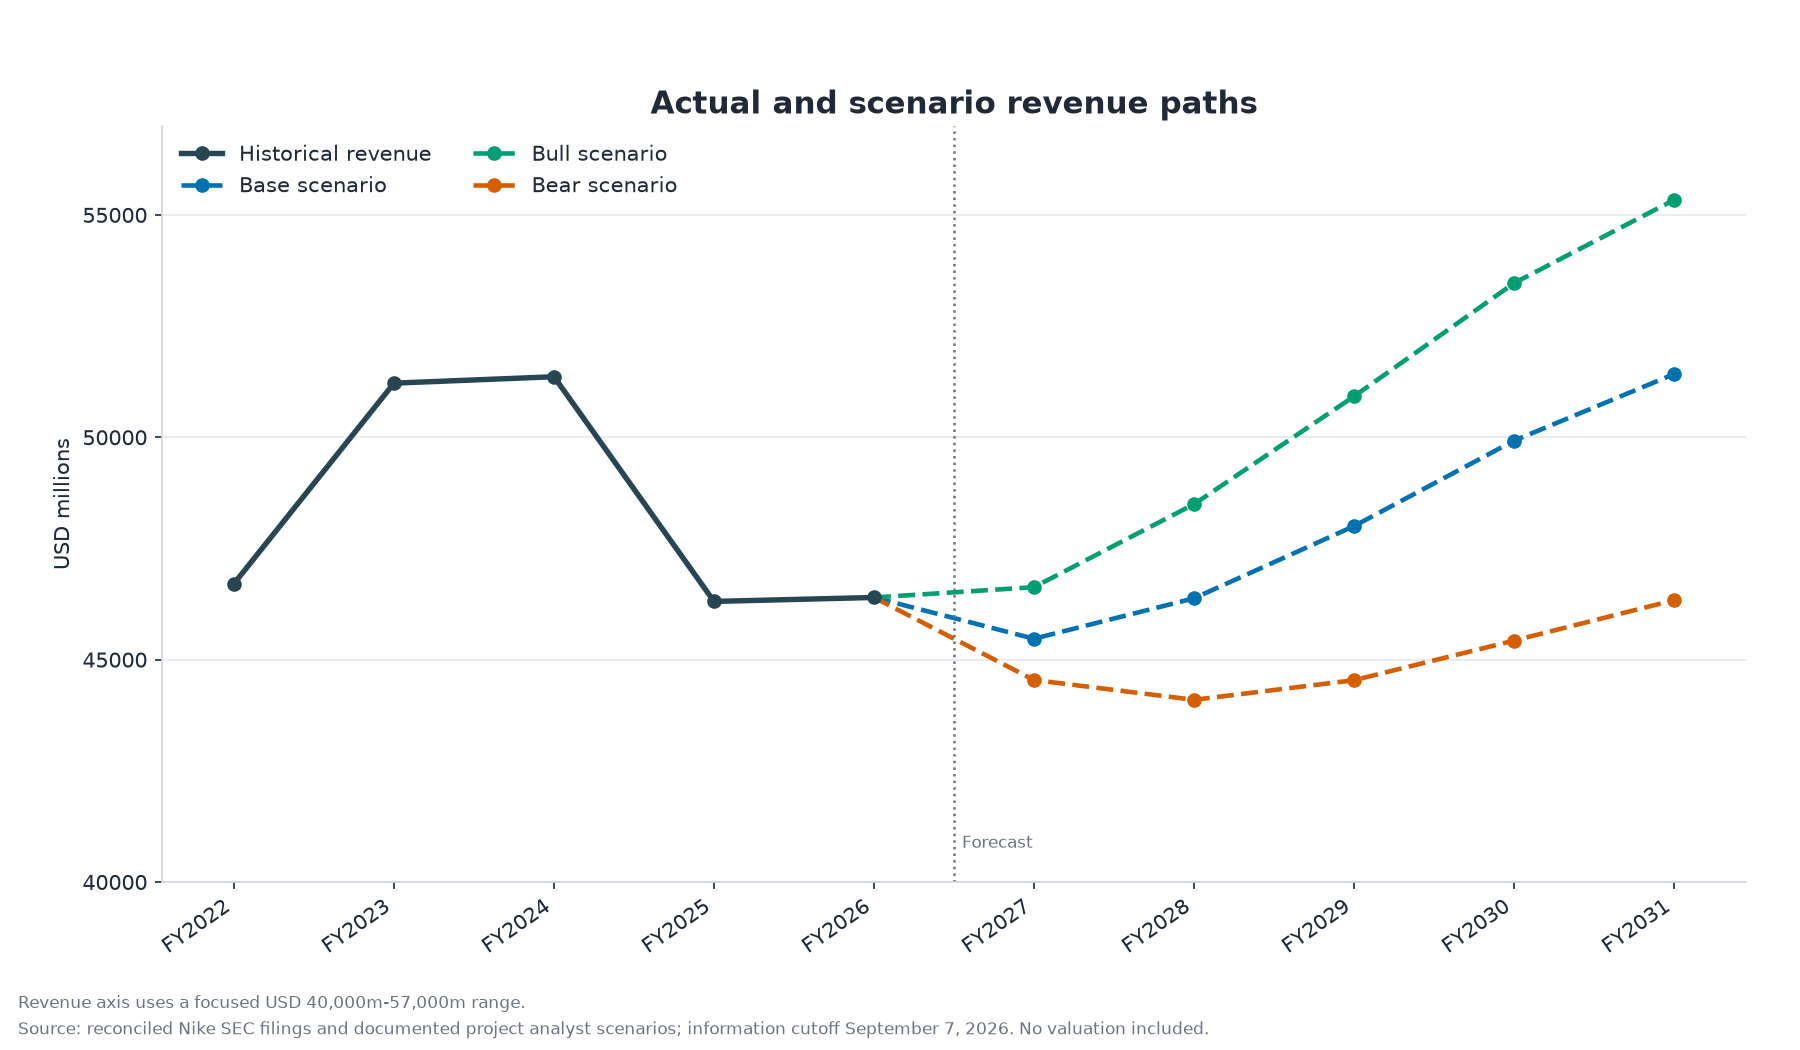

In [3]:
display(Image(data=figure_to_png_bytes(forecast_revenue_chart(long_rows))))

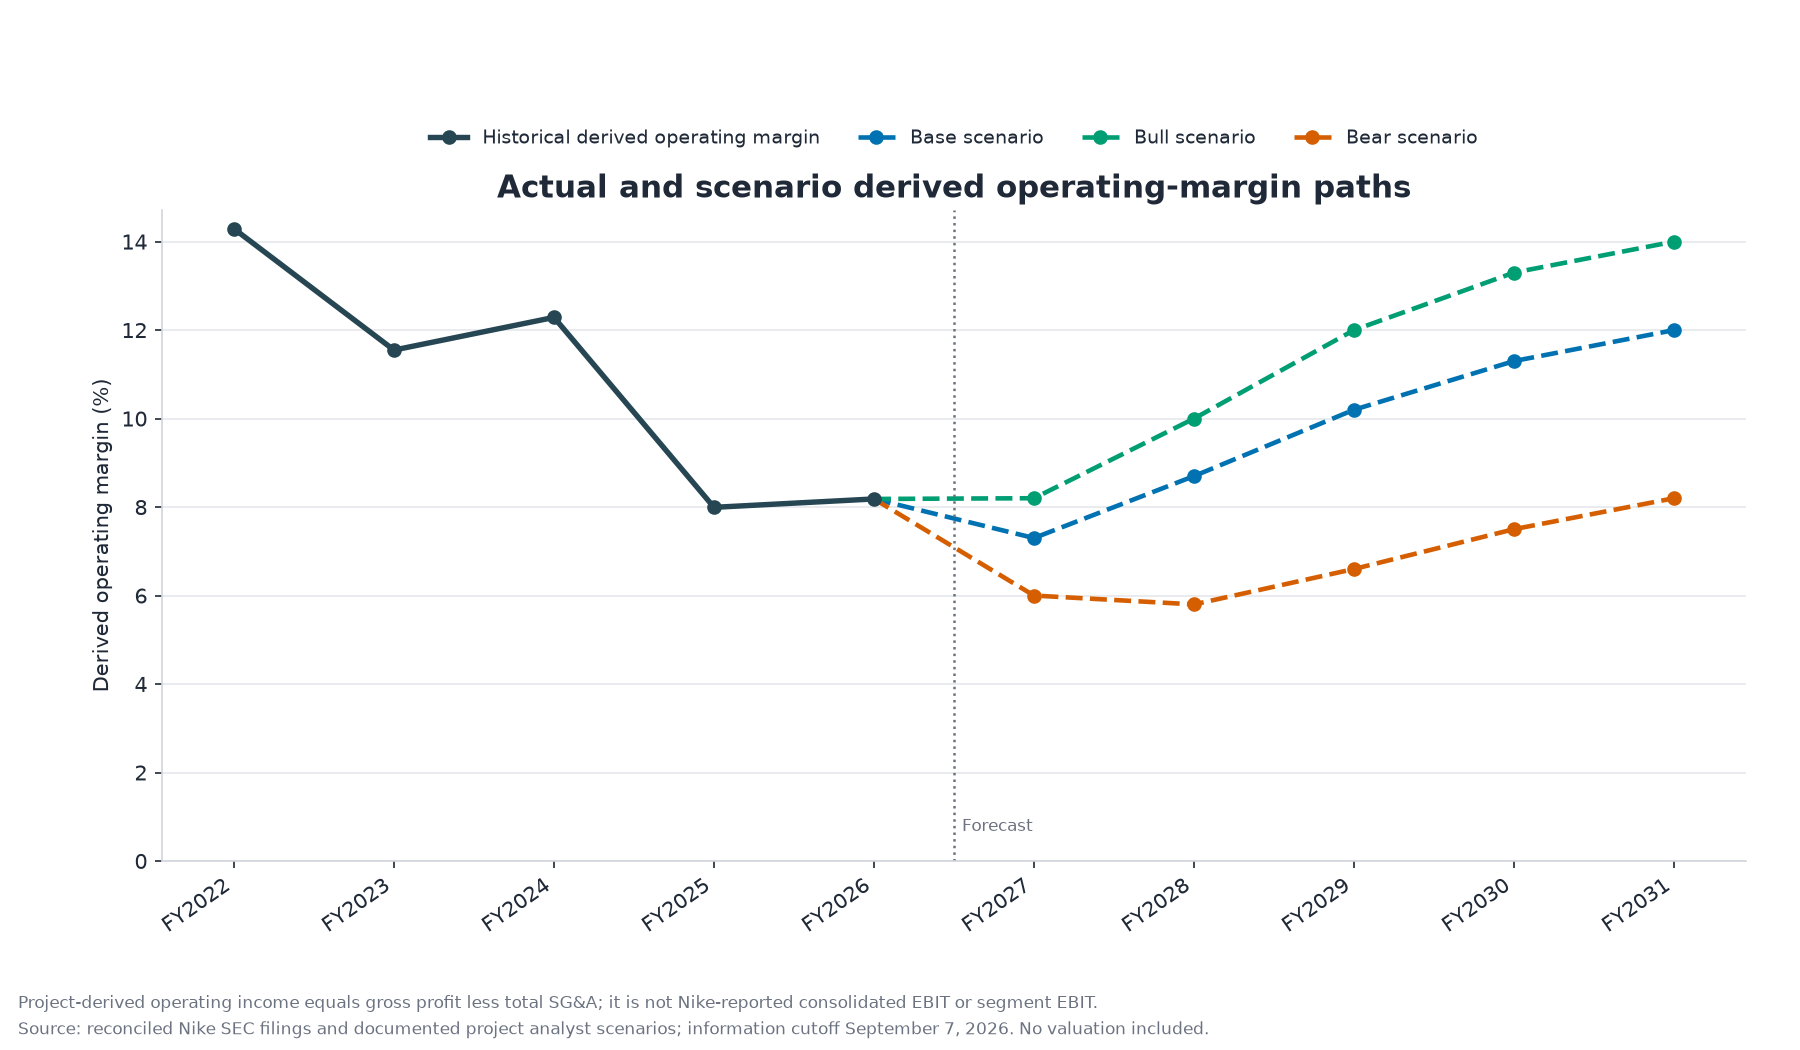

In [4]:
display(Image(data=figure_to_png_bytes(forecast_operating_margin_chart(long_rows))))

## Key scenario outputs

This compact view highlights the outputs most useful for comparing the operating scenarios. USD-million figures are rounded to whole millions and rates to one decimal percentage point for presentation. The [long-form forecast](../outputs/tables/scenario_forecast_long.csv) retains the authoritative full-precision values and calculation lineage.

In [5]:
key_metrics = {
    "revenue": "Revenue (USDm)",
    "operating_margin": "Derived operating margin",
    "fcff": "FCFF (USDm)",
    "fcff_margin": "FCFF margin",
}
forecast_years = [f"FY{year}" for year in range(2027, 2032)]
summary_frame = pd.DataFrame(summary_rows)
key_output_rows = []
for _, row in summary_frame[summary_frame["metric"].isin(key_metrics)].iterrows():
    output_row = {"Scenario": row["scenario"].title(), "Metric": key_metrics[row["metric"]]}
    for year in forecast_years:
        value = Decimal(row[year])
        output_row[year] = f"{value * 100:.1f}%" if row["unit"] == "Decimal" else f"{value:,.0f}"
    key_output_rows.append(output_row)
display(pd.DataFrame(key_output_rows).set_index(["Scenario", "Metric"]))

FY2027  FY2028  FY2029  FY2030  FY2031
Scenario Metric                                                          
Base     Revenue (USDm)            45,470  46,379  48,003  49,923  51,421
         Derived operating margin       0       0       0       0       0
         FCFF (USDm)                3,128   3,226   3,789   4,355   4,773
         FCFF margin                    0       0       0       0       0
Bull     Revenue (USDm)            46,630  48,495  50,920  53,466  55,337
         Derived operating margin       0       0       0       0       0
         FCFF (USDm)                3,445   3,727   4,626   5,417   5,994
         FCFF margin                    0       0       0       0       0
Bear     Revenue (USDm)            44,542  44,097  44,538  45,428  46,337
         Derived operating margin       0       0       0       0       0
         FCFF (USDm)                2,540   2,161   2,359   2,632   2,988
         FCFF margin                    0       0       0       0       0

## Operating working capital and FY2027 FCFF bridge

The aggregate operating-NWC proxy removes cash, short-term investments, short-term financing, current long-term debt, and current operating lease liabilities from current balances. It still may contain tax, dividend, and other aggregated balances. FY2026 opening ONWC is USD 5,507 million. The tariff receivable is already embedded, so no separate later collection is added to FCFF.

FY2027 closing ONWC is USD 5,047 million in base, USD 5,036 million in bull, and USD 5,211 million in bear. The respective changes of -USD 460 million, -USD 471 million, and -USD 296 million are sources of cash. That normalization is a material reason FY2027 forecast FCFF exceeds the comparable FY2026 historical FCFF bridge in every scenario; the increase is not purely operating-driven.

In [6]:
metrics = {"operating_nwc_proxy", "change_in_operating_nwc", "fcff", "fcff_margin"}
bridge = pd.DataFrame(summary_rows)
display(bridge[bridge["metric"].isin(metrics)][["scenario", "metric", "FY2026_actual", "FY2027"]])

,scenario,metric,FY2026_actual,FY2027
15,base,operating_nwc_proxy,5507,5047
17,base,change_in_operating_nwc,1355,-460
18,base,fcff,1734,3128
19,base,fcff_margin,0.037,0.069
35,bull,operating_nwc_proxy,5507,5036
37,bull,change_in_operating_nwc,1355,-471
38,bull,fcff,1734,3445
39,bull,fcff_margin,0.037,0.074
55,bear,operating_nwc_proxy,5507,5211
57,bear,change_in_operating_nwc,1355,-296


## FCFF and reinvestment

FY2031 FCFF is USD 4,773 million in base, USD 5,994 million in bull, and USD 2,988 million in bear. Bull-case capex is generally highest as a percentage of revenue, so the upside case is not created by suppressing reinvestment. Positive changes in operating NWC reduce FCFF; negative changes release cash.

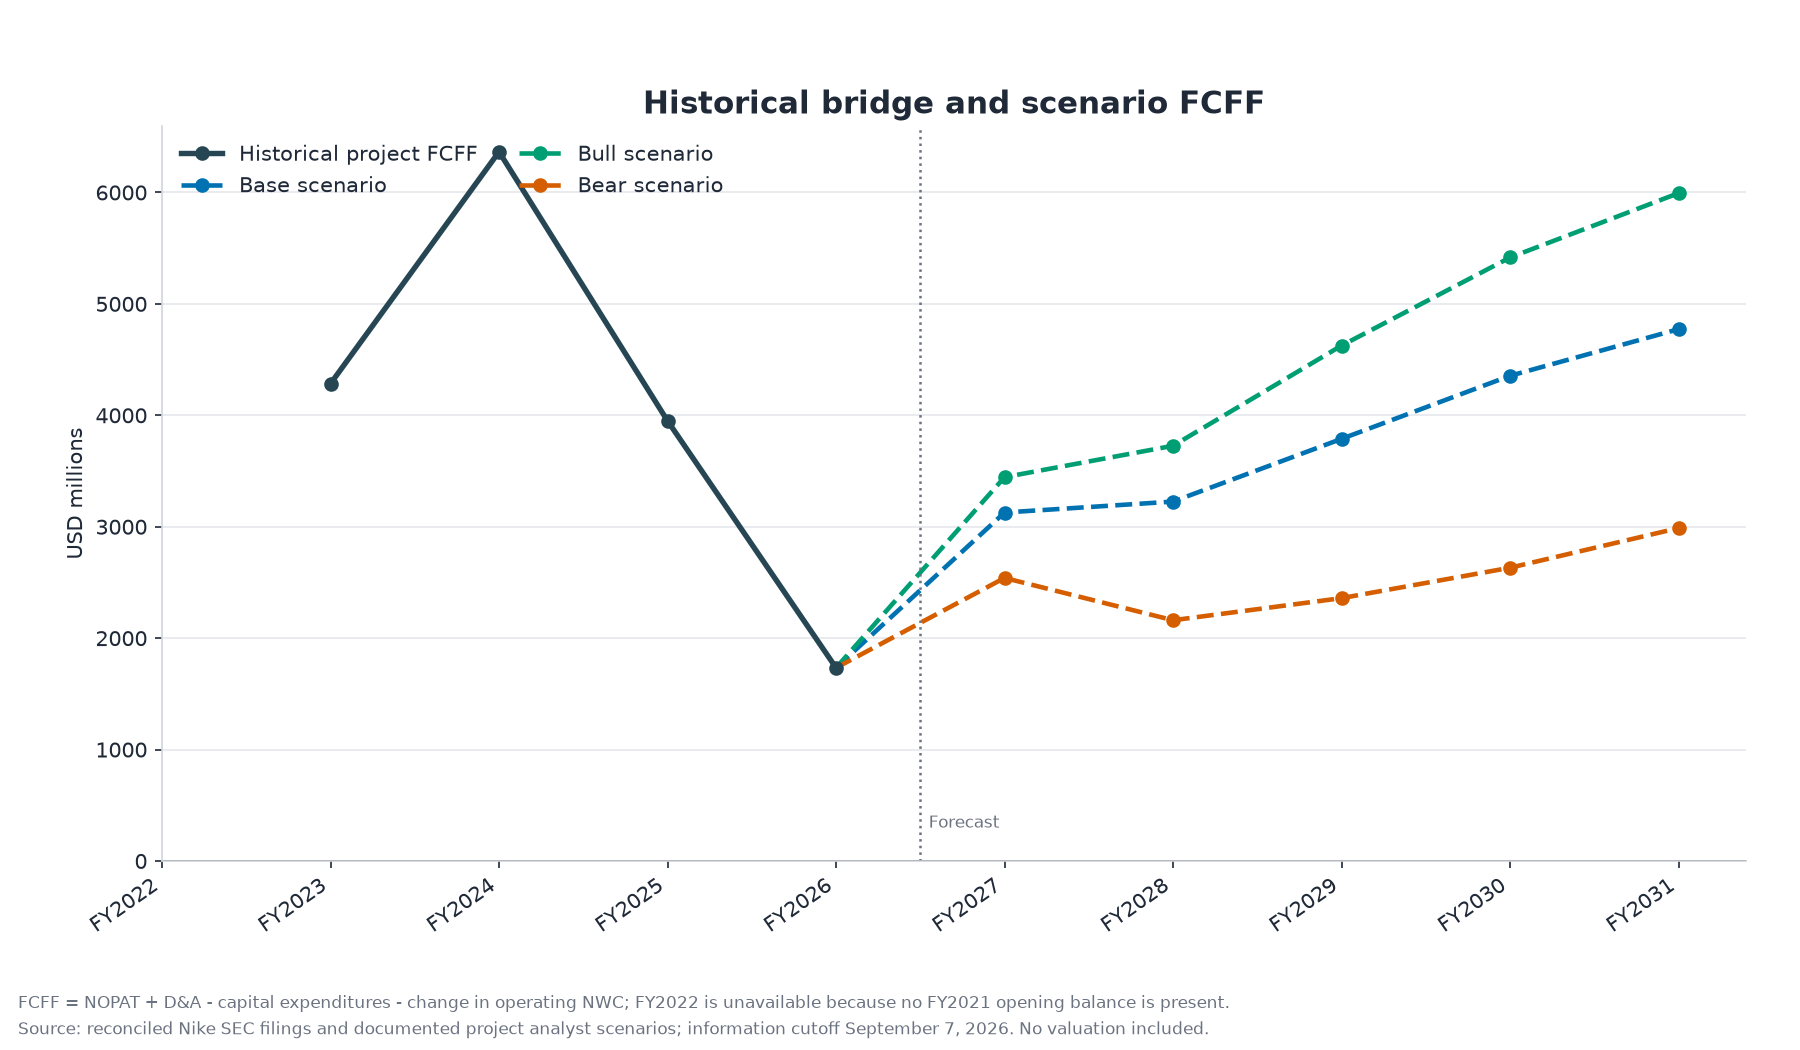

In [7]:
display(Image(data=figure_to_png_bytes(forecast_fcff_chart(long_rows))))

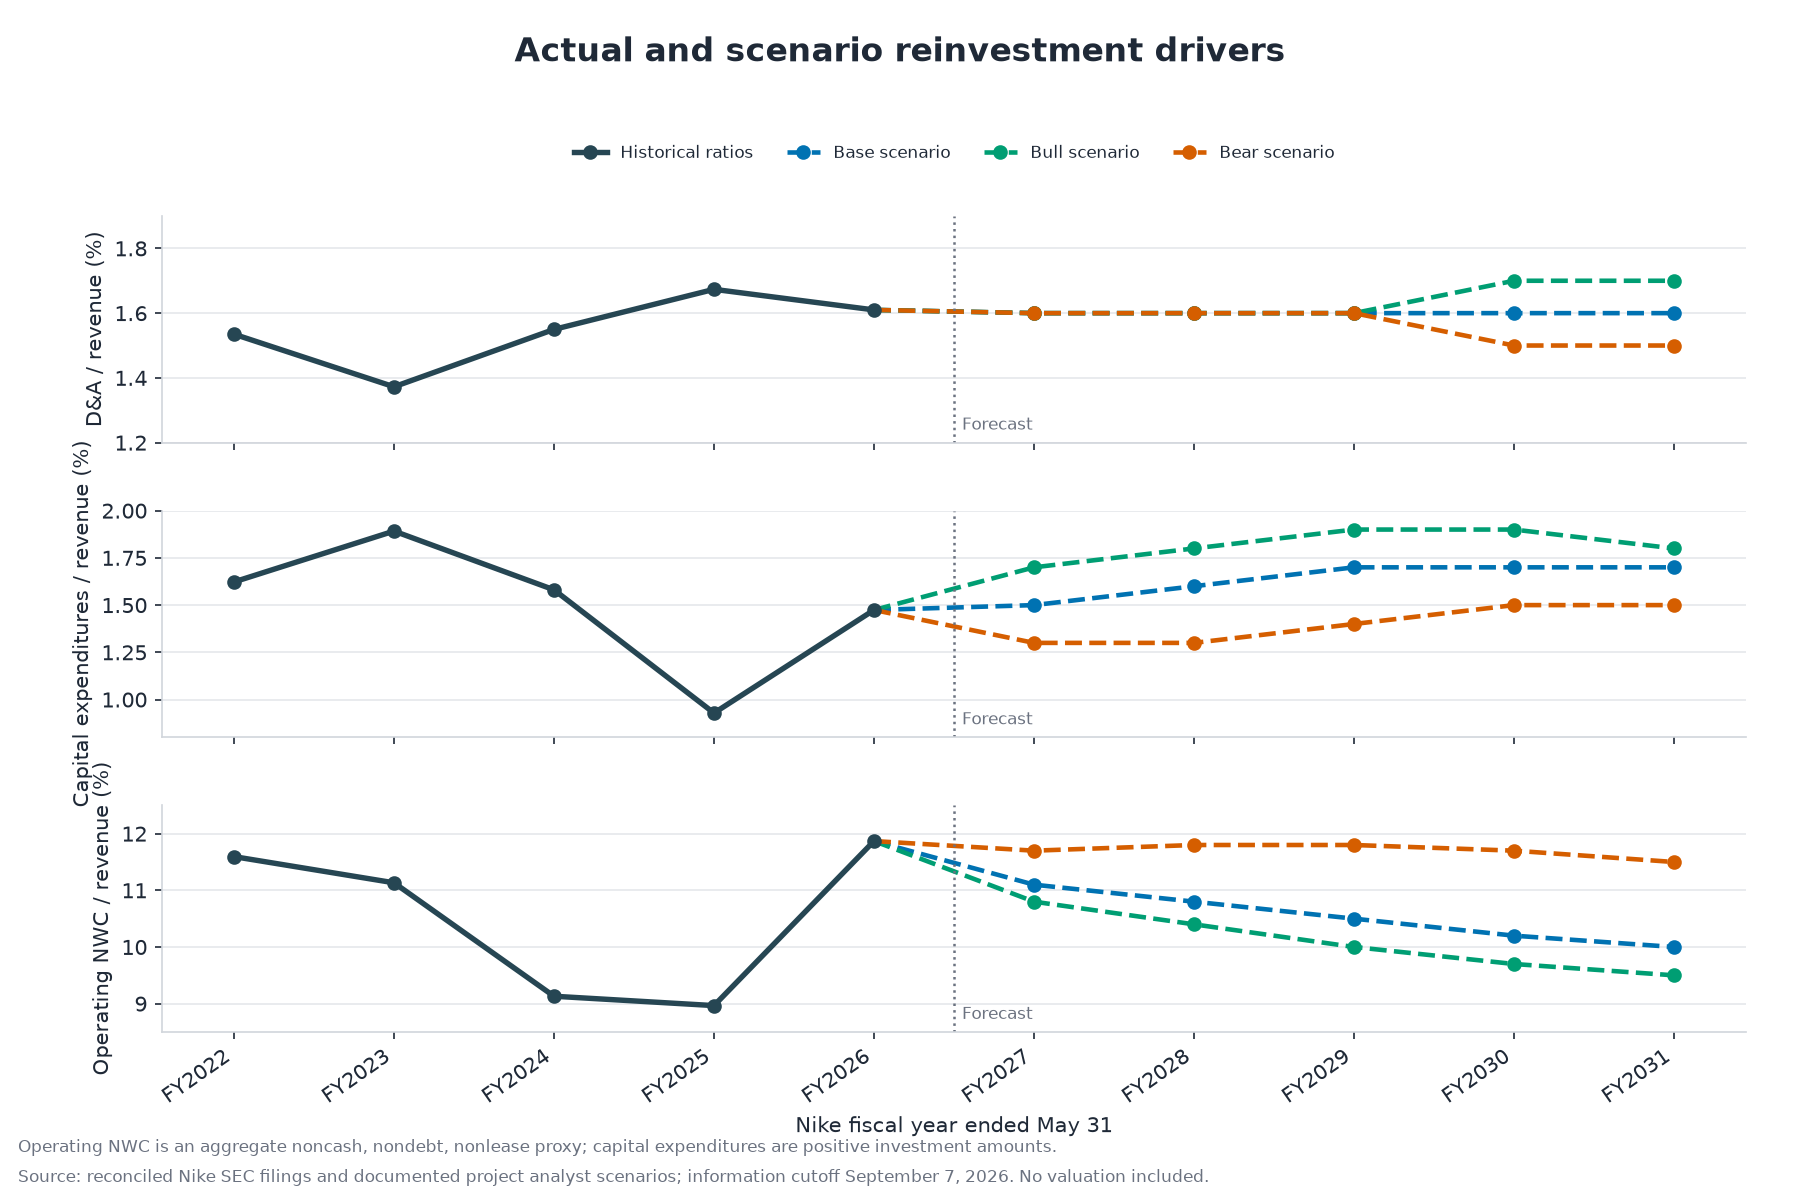

In [8]:
display(Image(data=figure_to_png_bytes(forecast_reinvestment_chart(long_rows))))

## Tax, leases, and interpretation limits

The normalized operating tax rate is 21.0% in every scenario. Without a separately documented NOL schedule, a future negative derived operating result would receive no automatic tax benefit. Lease expense remains operating, while lease liabilities remain outside debt and operating NWC; no separate lease principal or imputed interest is added to FCFF.

Five annual scenarios cannot resolve quarterly timing, channel mix, currency effects, or the exact composition of aggregate working capital. The FY2031 endpoints are operating states for later review, not terminal-value assumptions. See [scenario rationale](../docs/scenario_rationale.md) and [limitations](../docs/limitations.md).

## Reproduction

From the repository root in Windows PowerShell:

```powershell
uv sync --locked --python 3.14.5
uv run nike-scenario-forecast
uv run nike-execute-notebook notebooks/02_scenario_forecast.ipynb --in-place
```

The forecast command uses only committed files and makes no network request.